In [23]:
!pip install -U "accelerate==0.25.0"

  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.13.0
    Uninstalling accelerate-1.13.0:
      Successfully uninstalled accelerate-1.13.0

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

import torch
from torch import nn

from datasets import load_from_disk
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import f1_score

/Users/aaradhyaacharya/anaconda3/lib/python3.11/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/Users/aaradhyaacharya/anaconda3/lib/python3.11/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [2]:
# paths+device

MODEL_CHECKPOINT = "emilyalsentzer/Bio_ClinicalBERT"

DATASET_DIR = Path("hf_datasets/tokenized_truncate")
ARTIFACTS_DIR = Path("artifacts")
MODEL_OUT_DIR = Path("models/bioclinicalbert_truncate")

MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


In [3]:
# load dataset + labels

tokenized = load_from_disk(str(DATASET_DIR))
tokenized

label_list = pd.read_csv(ARTIFACTS_DIR / "label_list.csv")["icd_code"].tolist()
num_labels = len(label_list)

print("Num labels:", num_labels)
print(label_list[:10])

pos_weight_path = ARTIFACTS_DIR / "pos_weight.npy"
use_pos_weight = pos_weight_path.exists()

if use_pos_weight:
    pos_weight = torch.tensor(np.load(pos_weight_path), dtype=torch.float)
    print("Loaded pos_weight:", pos_weight.shape)
else:
    pos_weight = None
    print("No pos_weight found; training without class weighting.")

Num labels: 50
['D62', 'D649', 'D696', 'E039', 'E1122', 'E119', 'E669', 'E785', 'E871', 'E872']
Loaded pos_weight: torch.Size([50])


In [4]:
# load tokenizer + data collator

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, use_fast=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [8]:
# build model config

config = AutoConfig.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=num_labels,
    problem_type="multi_label_classification",
    id2label={i: label for i, label in enumerate(label_list)},
    label2id={label: i for i, label in enumerate(label_list)}
)

base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    config=config
)

/Users/aaradhyaacharya/anaconda3/lib/python3.11/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
# custom trainer with optional BCE

class WeightedMultiLabelTrainer(Trainer):
    def __init__(self, pos_weight=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.pos_weight = pos_weight

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        logits = outputs.logits

        if self.pos_weight is not None:
            loss_fct = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight.to(logits.device))
        else:
            loss_fct = nn.BCEWithLogitsLoss()

        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [13]:
# metrics

def precision_recall_at_k(y_true_bin, y_score, k=5):
    precisions, recalls = [], []
    for i in range(y_true_bin.shape[0]):
        true_idx = set(np.where(y_true_bin[i] == 1)[0])
        if not true_idx:
            continue
        topk_idx = set(np.argsort(y_score[i])[-k:])
        precisions.append(len(true_idx & topk_idx) / k)
        recalls.append(len(true_idx & topk_idx) / len(true_idx))
    return float(np.mean(precisions)), float(np.mean(recalls))

THRESHOLD = 0.5

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    preds = (probs >= THRESHOLD).astype(int)

    micro_f1 = f1_score(labels, preds, average="micro", zero_division=0)
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)

    p5, r5 = precision_recall_at_k(labels, probs, k=5)

    return {
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
        "precision_at_5": p5,
        "recall_at_5": r5
    }

In [15]:
# training arguments

training_args = TrainingArguments(
    output_dir=str(MODEL_OUT_DIR / "checkpoints"),
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="micro_f1",
    greater_is_better=True,

    num_train_epochs=1,
    learning_rate=2e-5,
    weight_decay=0.01,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=1,

    fp16=False,
    report_to="none",
    seed=42
)

In [17]:
# initilalize trainer

trainer = WeightedMultiLabelTrainer(
    model=base_model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    pos_weight=pos_weight
)

In [19]:
# train

train_result = trainer.train()
train_result

You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Precision At 5,Recall At 5
1,0.898700,0.892895,0.391844,0.377791,0.399844,0.429173


TrainOutput(global_step=20143, training_loss=0.9587268799991681, metrics={'train_runtime': 121092.5051, 'train_samples_per_second': 0.665, 'train_steps_per_second': 0.166, 'total_flos': 2.1208257082312704e+16, 'train_loss': 0.9587268799991681, 'epoch': 1.0})

In [20]:
# validation results

val_metrics = trainer.evaluate(tokenized["validation"])
val_metrics

{'eval_loss': 0.8928953409194946,
 'eval_micro_f1': 0.3918444597384721,
 'eval_macro_f1': 0.3777911657764006,
 'eval_precision_at_5': 0.39984362783424554,
 'eval_recall_at_5': 0.4291733309020482,
 'eval_runtime': 2271.8088,
 'eval_samples_per_second': 5.067,
 'eval_steps_per_second': 1.267,
 'epoch': 1.0}

In [21]:
# test set evalutaion

test_metrics = trainer.evaluate(tokenized["test"])
test_metrics

{'eval_loss': 0.8850677609443665,
 'eval_micro_f1': 0.39165999557152836,
 'eval_macro_f1': 0.3768535388729527,
 'eval_precision_at_5': 0.3976890665044959,
 'eval_recall_at_5': 0.42752730918998344,
 'eval_runtime': 41794.9076,
 'eval_samples_per_second': 0.551,
 'eval_steps_per_second': 0.138,
 'epoch': 1.0}

In [22]:
# save final model + tokenizer

trainer.save_model(str(MODEL_OUT_DIR / "final"))
tokenizer.save_pretrained(str(MODEL_OUT_DIR / "final"))

print("Saved model to:", (MODEL_OUT_DIR / "final").resolve())

Saved model to: /Users/aaradhyaacharya/Documents/semesters/grad/sem4/ICD_NLP/models/bioclinicalbert_truncate/final


In [23]:
# get test predictions

pred_output = trainer.predict(tokenized["test"])

test_logits = pred_output.predictions
test_labels = pred_output.label_ids

test_probs = 1 / (1 + np.exp(-test_logits))
test_preds = (test_probs >= THRESHOLD).astype(int)

print(test_logits.shape, test_labels.shape, test_probs.shape, test_preds.shape)

(23021, 50) (23021, 50) (23021, 50) (23021, 50)


In [24]:
# save test predictions

pred_dir = Path("predictions")
pred_dir.mkdir(exist_ok=True)

np.save(pred_dir / "transformer_test_logits.npy", test_logits)
np.save(pred_dir / "transformer_test_probs.npy", test_probs)
np.save(pred_dir / "transformer_test_preds.npy", test_preds)
np.save(pred_dir / "transformer_test_labels.npy", test_labels)

print("Saved test predictions to:", pred_dir.resolve())

Saved test predictions to: /Users/aaradhyaacharya/Documents/semesters/grad/sem4/ICD_NLP/predictions


In [25]:
# save metrics table

results = {
    "model": "BioClinicalBERT_truncate",
    "threshold": THRESHOLD,
    "val_micro_f1": val_metrics.get("eval_micro_f1"),
    "val_macro_f1": val_metrics.get("eval_macro_f1"),
    "val_precision_at_5": val_metrics.get("eval_precision_at_5"),
    "val_recall_at_5": val_metrics.get("eval_recall_at_5"),
    "test_micro_f1": test_metrics.get("eval_micro_f1"),
    "test_macro_f1": test_metrics.get("eval_macro_f1"),
    "test_precision_at_5": test_metrics.get("eval_precision_at_5"),
    "test_recall_at_5": test_metrics.get("eval_recall_at_5")
}

results_df = pd.DataFrame([results])
results_df

results_df.to_csv("transformer_results.csv", index=False)
print("Saved transformer_results.csv")

Saved transformer_results.csv


In [26]:
# threshold sweep

# Sometimes 0.5 is not optimal for multi-label tasks.
# This cell finds a better threshold on the validation set.

val_pred_output = trainer.predict(tokenized["validation"])
val_logits = val_pred_output.predictions
val_labels = val_pred_output.label_ids
val_probs = 1 / (1 + np.exp(-val_logits))

thresholds = np.arange(0.1, 0.91, 0.05)
sweep_rows = []

for t in thresholds:
    val_preds_t = (val_probs >= t).astype(int)
    micro = f1_score(val_labels, val_preds_t, average="micro", zero_division=0)
    macro = f1_score(val_labels, val_preds_t, average="macro", zero_division=0)
    p5, r5 = precision_recall_at_k(val_labels, val_probs, k=5)

    sweep_rows.append({
        "threshold": t,
        "micro_f1": micro,
        "macro_f1": macro,
        "precision_at_5": p5,
        "recall_at_5": r5
    })

threshold_df = pd.DataFrame(sweep_rows)
threshold_df.sort_values("micro_f1", ascending=False).head()

best_threshold = threshold_df.sort_values("micro_f1", ascending=False).iloc[0]["threshold"]
best_threshold

0.6500000000000001

In [27]:
# rescore with best threshold

best_test_preds = (test_probs >= best_threshold).astype(int)

best_test_micro = f1_score(test_labels, best_test_preds, average="micro", zero_division=0)
best_test_macro = f1_score(test_labels, best_test_preds, average="macro", zero_division=0)
best_test_p5, best_test_r5 = precision_recall_at_k(test_labels, test_probs, k=5)

print("Best threshold from validation:", best_threshold)
print("Test Micro-F1:", round(best_test_micro, 4))
print("Test Macro-F1:", round(best_test_macro, 4))
print("Test P@5:", round(best_test_p5, 4))
print("Test R@5:", round(best_test_r5, 4))

Best threshold from validation: 0.6500000000000001
Test Micro-F1: 0.4331
Test Macro-F1: 0.4084
Test P@5: 0.3977
Test R@5: 0.4275


In [28]:
# save threshold sweep

threshold_df.to_csv("transformer_threshold_sweep.csv", index=False)
print("Saved transformer_threshold_sweep.csv")

Saved transformer_threshold_sweep.csv


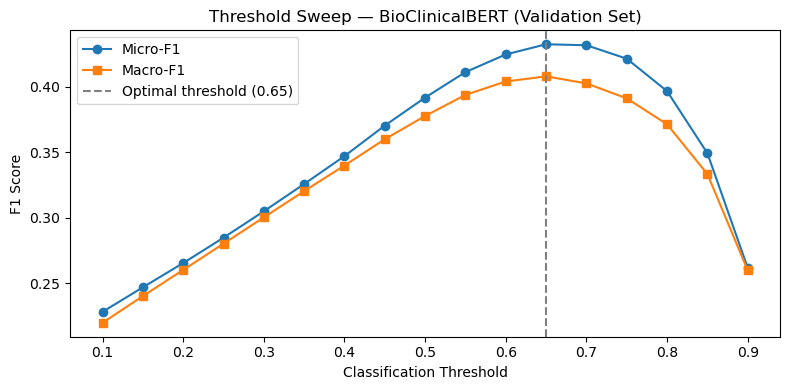

In [2]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv("transformer_threshold_sweep.csv")
plt.figure(figsize=(8,4))
plt.plot(df["threshold"], df["micro_f1"], label="Micro-F1", marker="o")
plt.plot(df["threshold"], df["macro_f1"], label="Macro-F1", marker="s")
plt.axvline(x=0.65, color="gray", linestyle="--", label="Optimal threshold (0.65)")
plt.xlabel("Classification Threshold"); plt.ylabel("F1 Score")
plt.title("Threshold Sweep — BioClinicalBERT (Validation Set)")
plt.legend(); plt.tight_layout()
plt.savefig("threshold_sweep_chart.png", dpi=150)